# Climate Evolution in Yaoundé — Exploratory Analysis
## Training period (2019–2022) and Deployment period (Apr–Jun 2026)

This notebook produces the climate-evolution figures for **Yaoundé**, the district
where the IoT network was deployed. It generates:

1. **2019–2022** monthly evolution of the four environmental variables, aggregated
   over the three Yaoundé health districts (Biyem Assi, Efoulan, Nkolndongo).
2. **April–June 2026** daily evolution over the deployment window.
3. A **seasonal climatology** (mean monthly cycle) to show the bimodal rainfall
   regime characteristic of Yaoundé's equatorial climate.

All figures are saved as PNG for the thesis.


## 0 · Setup

In [1]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi':120,'savefig.dpi':150,'axes.titlesize':12,
                     'axes.labelsize':10,'font.size':10})
# Consistent colours per variable
VARC = {'Temperature_C':'#e74c3c','Humidity':'#2980b9',
        'Pressure_hPa':'#8e44ad','Precipitation_mm':'#27ae60'}
VARLAB = {'Temperature_C':'Temperature (°C)','Humidity':'Relative humidity (%)',
          'Pressure_hPa':'Pressure (hPa)','Precipitation_mm':'Precipitation (mm)'}
print('Setup OK')


Setup OK


## 1 · Load and aggregate Yaoundé climate (2019–2022)

In [2]:
df = pd.read_csv('cameroon_districts_climate.csv', parse_dates=['Date'])
YDE_DISTRICTS = ['Biyem Assi','Efoulan','Nkolndongo']  # the 3 Yaoundé urban health districts
yde = df[df['Location'].isin(YDE_DISTRICTS)].copy()
print(f'Yaoundé rows: {len(yde)} across {yde.Location.nunique()} districts')

# Average the districts per day -> one Yaoundé daily series
daily = yde.groupby('Date').agg(
    Temperature_C=('Temperature_C','mean'),
    Humidity=('Humidity_%','mean'),
    Pressure_hPa=('Pressure_hPa','mean'),
    Precipitation_mm=('Precipitation_mm','mean')).reset_index()

# Monthly: means for state variables, SUM for precipitation
monthly = daily.set_index('Date').resample('MS').agg(
    Temperature_C=('Temperature_C','mean'),
    Humidity=('Humidity','mean'),
    Pressure_hPa=('Pressure_hPa','mean'),
    Precipitation_mm=('Precipitation_mm','sum')).reset_index()
print(f'Monthly series: {len(monthly)} months ({monthly.Date.min().date()} to {monthly.Date.max().date()})')
monthly.head()


Yaoundé rows: 3465 across 3 districts
Monthly series: 38 months (2019-01-01 to 2022-02-01)


,Date,Temperature_C,Humidity,Pressure_hPa,Precipitation_mm
0,2019-01-01,24.125484,80.672473,934.604516,43.900000
1,2019-02-01,24.502857,79.540476,933.870714,97.866667
2,2019-03-01,23.930968,86.183011,934.168280,148.200000
3,2019-04-01,23.910889,87.994667,933.939333,160.700000
4,2019-05-01,23.337204,89.361828,934.367097,205.800000


## 2 · Figure — Yaoundé monthly climate evolution 2019–2022

Four stacked panels sharing the time axis, so the seasonal cycles align visually.


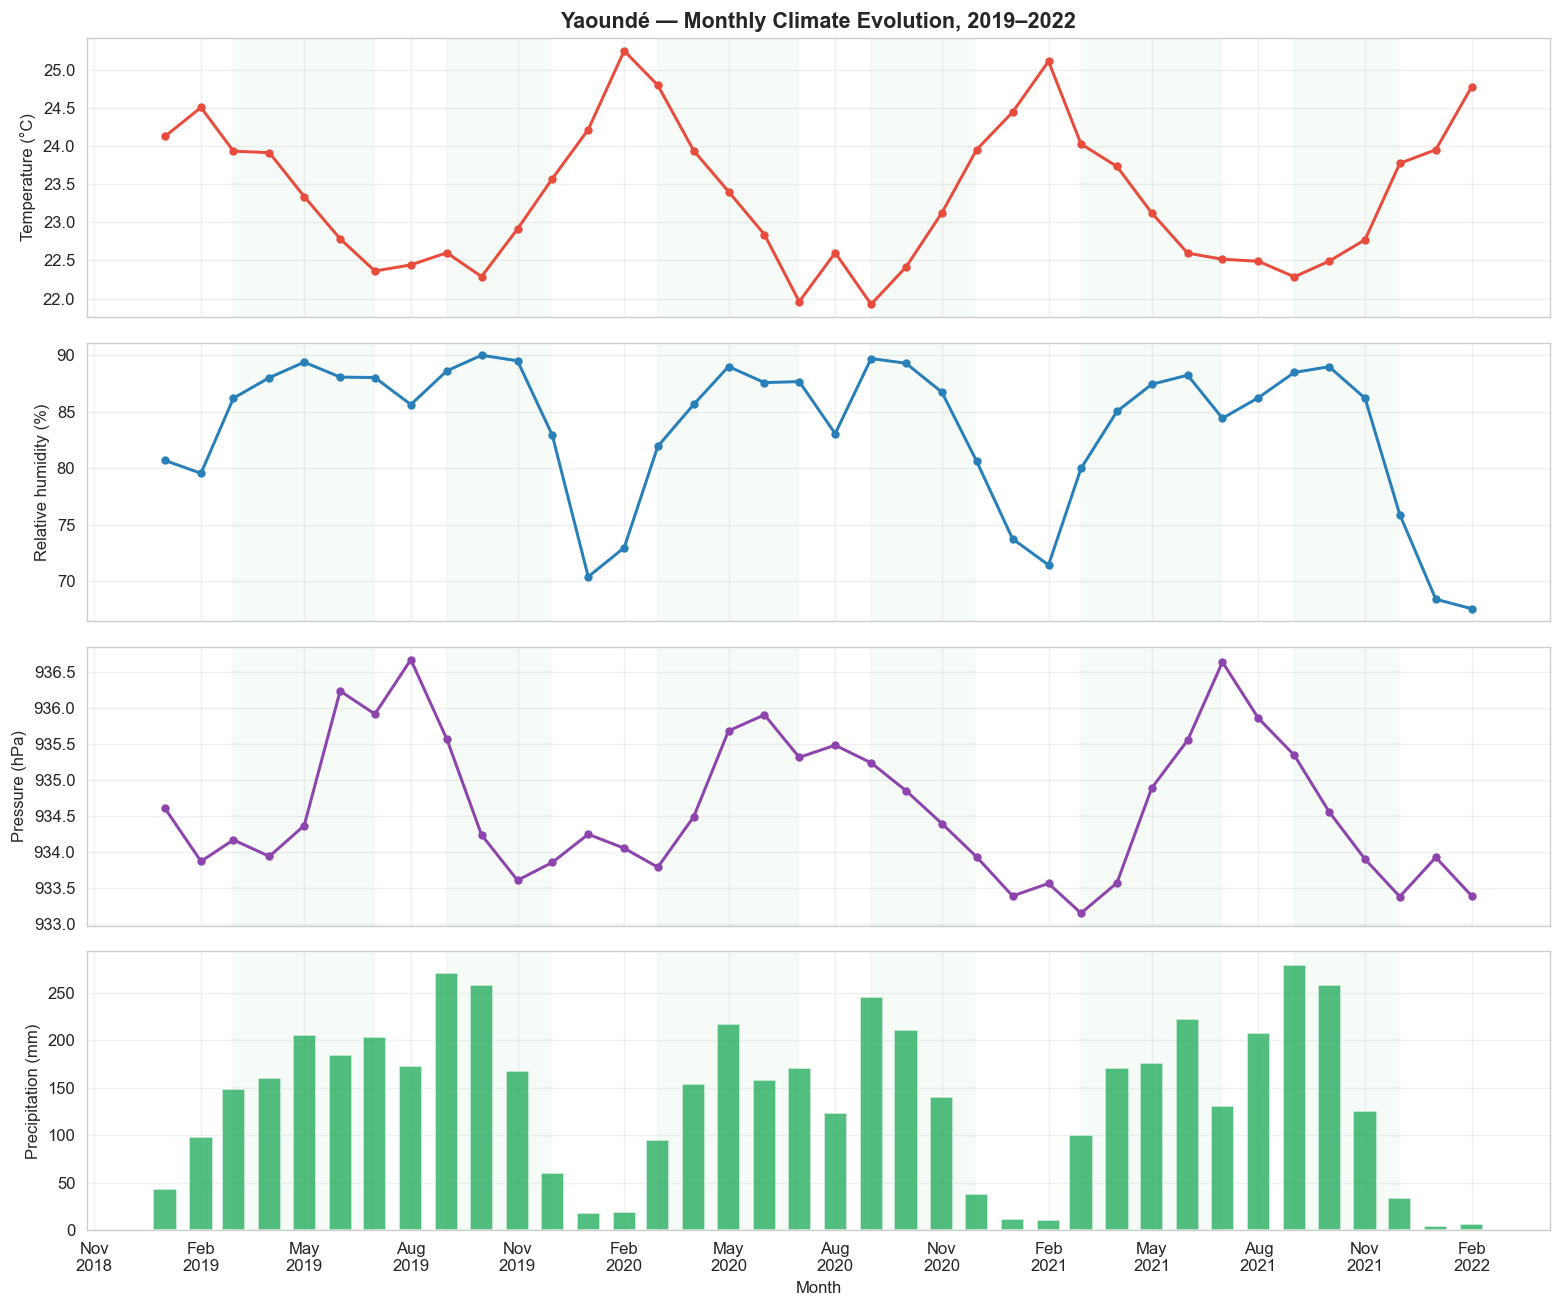

Saved yde_climate_2019_2022.png


In [3]:
fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
vars_order = ['Temperature_C','Humidity','Pressure_hPa','Precipitation_mm']
for ax, v in zip(axes, vars_order):
    if v == 'Precipitation_mm':
        ax.bar(monthly['Date'], monthly[v], width=20, color=VARC[v], alpha=0.8, label=VARLAB[v])
    else:
        ax.plot(monthly['Date'], monthly[v], '-o', color=VARC[v], ms=4, lw=1.8, label=VARLAB[v])
    ax.set_ylabel(VARLAB[v]); ax.grid(True, alpha=0.3)
    # shade the rainy seasons lightly to guide the eye (Mar-Jun, Sep-Nov)
    for yr in [2019,2020,2021]:
        ax.axvspan(pd.Timestamp(f'{yr}-03-01'), pd.Timestamp(f'{yr}-06-30'), color='#27ae60', alpha=0.04)
        ax.axvspan(pd.Timestamp(f'{yr}-09-01'), pd.Timestamp(f'{yr}-11-30'), color='#27ae60', alpha=0.04)
axes[0].set_title('Yaoundé — Monthly Climate Evolution, 2019–2022', fontsize=13, fontweight='bold')
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[-1].set_xlabel('Month')
plt.tight_layout()
plt.savefig('yde_climate_2019_2022.png', bbox_inches='tight'); plt.show()
print('Saved yde_climate_2019_2022.png')


## 3 · Figure — Seasonal climatology (mean monthly cycle)

Averaging each calendar month across the years exposes Yaoundé's **bimodal rainfall
regime** (two wet seasons) more clearly than the raw time series.


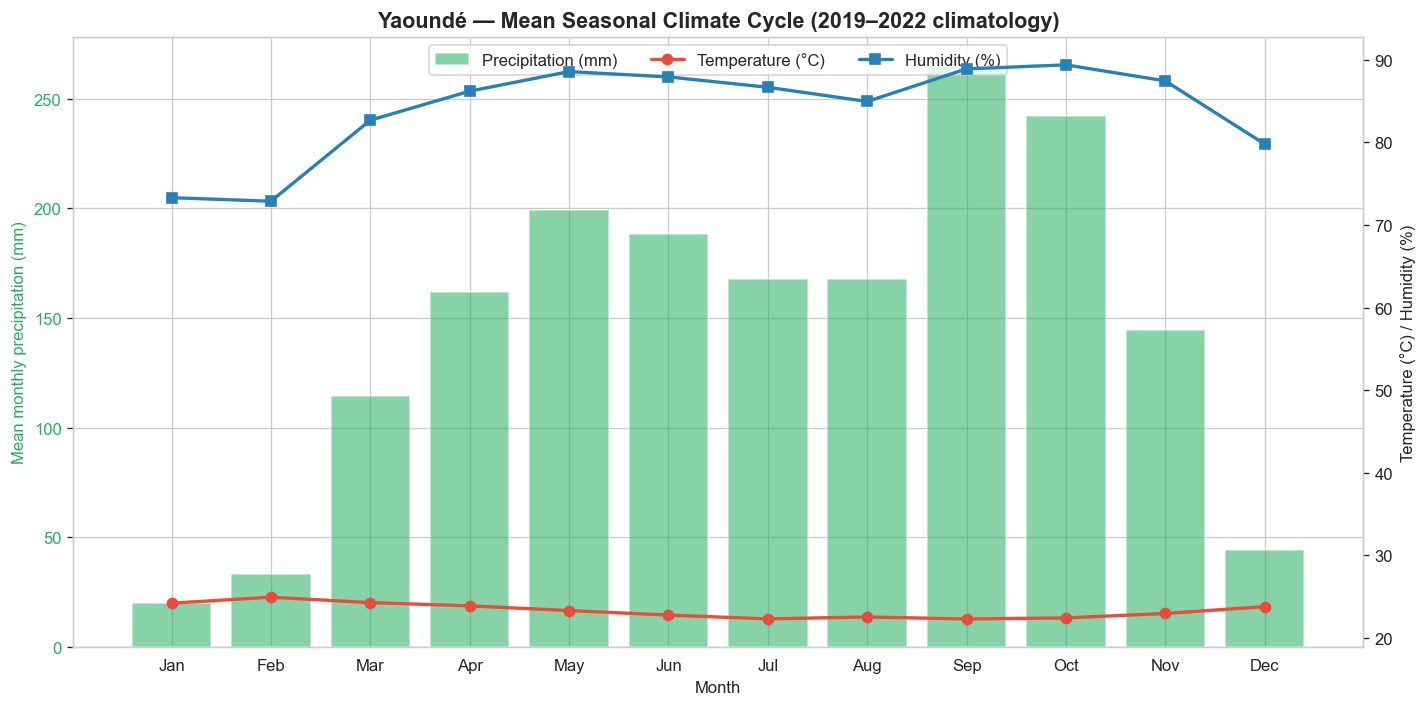

Bimodal rainfall peaks (months): [9, 10]


In [4]:
clim = monthly.copy()
clim['month'] = clim['Date'].dt.month
season = clim.groupby('month').agg(
    Temperature_C=('Temperature_C','mean'),
    Humidity=('Humidity','mean'),
    Precipitation_mm=('Precipitation_mm','mean')).reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax1 = plt.subplots(figsize=(12,6))
# Precip as bars
ax1.bar(season['month'], season['Precipitation_mm'], color=VARC['Precipitation_mm'],
        alpha=0.55, label='Precipitation (mm)')
ax1.set_xlabel('Month'); ax1.set_ylabel('Mean monthly precipitation (mm)', color=VARC['Precipitation_mm'])
ax1.set_xticks(range(1,13)); ax1.set_xticklabels(month_names)
ax1.tick_params(axis='y', labelcolor=VARC['Precipitation_mm'])
# Temp + humidity on secondary axis
ax2 = ax1.twinx()
ax2.plot(season['month'], season['Temperature_C'], '-o', color=VARC['Temperature_C'], lw=2, label='Temperature (°C)')
ax2.plot(season['month'], season['Humidity'], '-s', color=VARC['Humidity'], lw=2, label='Humidity (%)')
ax2.set_ylabel('Temperature (°C) / Humidity (%)')
ax2.grid(False)
# Combined legend
l1,lb1 = ax1.get_legend_handles_labels(); l2,lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc='upper center', ncol=3, frameon=True)
plt.title('Yaoundé — Mean Seasonal Climate Cycle (2019–2022 climatology)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('yde_climatology.png', bbox_inches='tight'); plt.show()
print('Bimodal rainfall peaks (months):', season.nlargest(2,'Precipitation_mm')['month'].tolist())


## 4 · Load Yaoundé deployment-period climate (Apr–Jun 2026)

In [5]:
dep = pd.read_csv('yaounde_climate_2026_apr_jun.csv', parse_dates=['Date'])
dep = dep.rename(columns={'Humidity_%':'Humidity'})
print(f'Deployment climate: {len(dep)} days ({dep.Date.min().date()} to {dep.Date.max().date()})')
dep.head()


Deployment climate: 139 days (2026-02-01 to 2026-06-19)


,Location,Region,Date,Temperature_C,Humidity,Pressure_hPa,Precipitation_mm
0,Yaounde,Centre,2026-02-01,25.00,71.17,934.45,0.0
1,Yaounde,Centre,2026-02-02,25.55,72.00,933.79,0.1
2,Yaounde,Centre,2026-02-03,24.23,80.88,933.79,0.7
3,Yaounde,Centre,2026-02-04,21.70,86.04,933.76,21.6
4,Yaounde,Centre,2026-02-05,22.80,75.75,933.47,0.0


## 5 · Figure — Yaoundé daily climate, deployment window (Apr–Jun 2026)

The same four variables at daily resolution over the IoT deployment period.


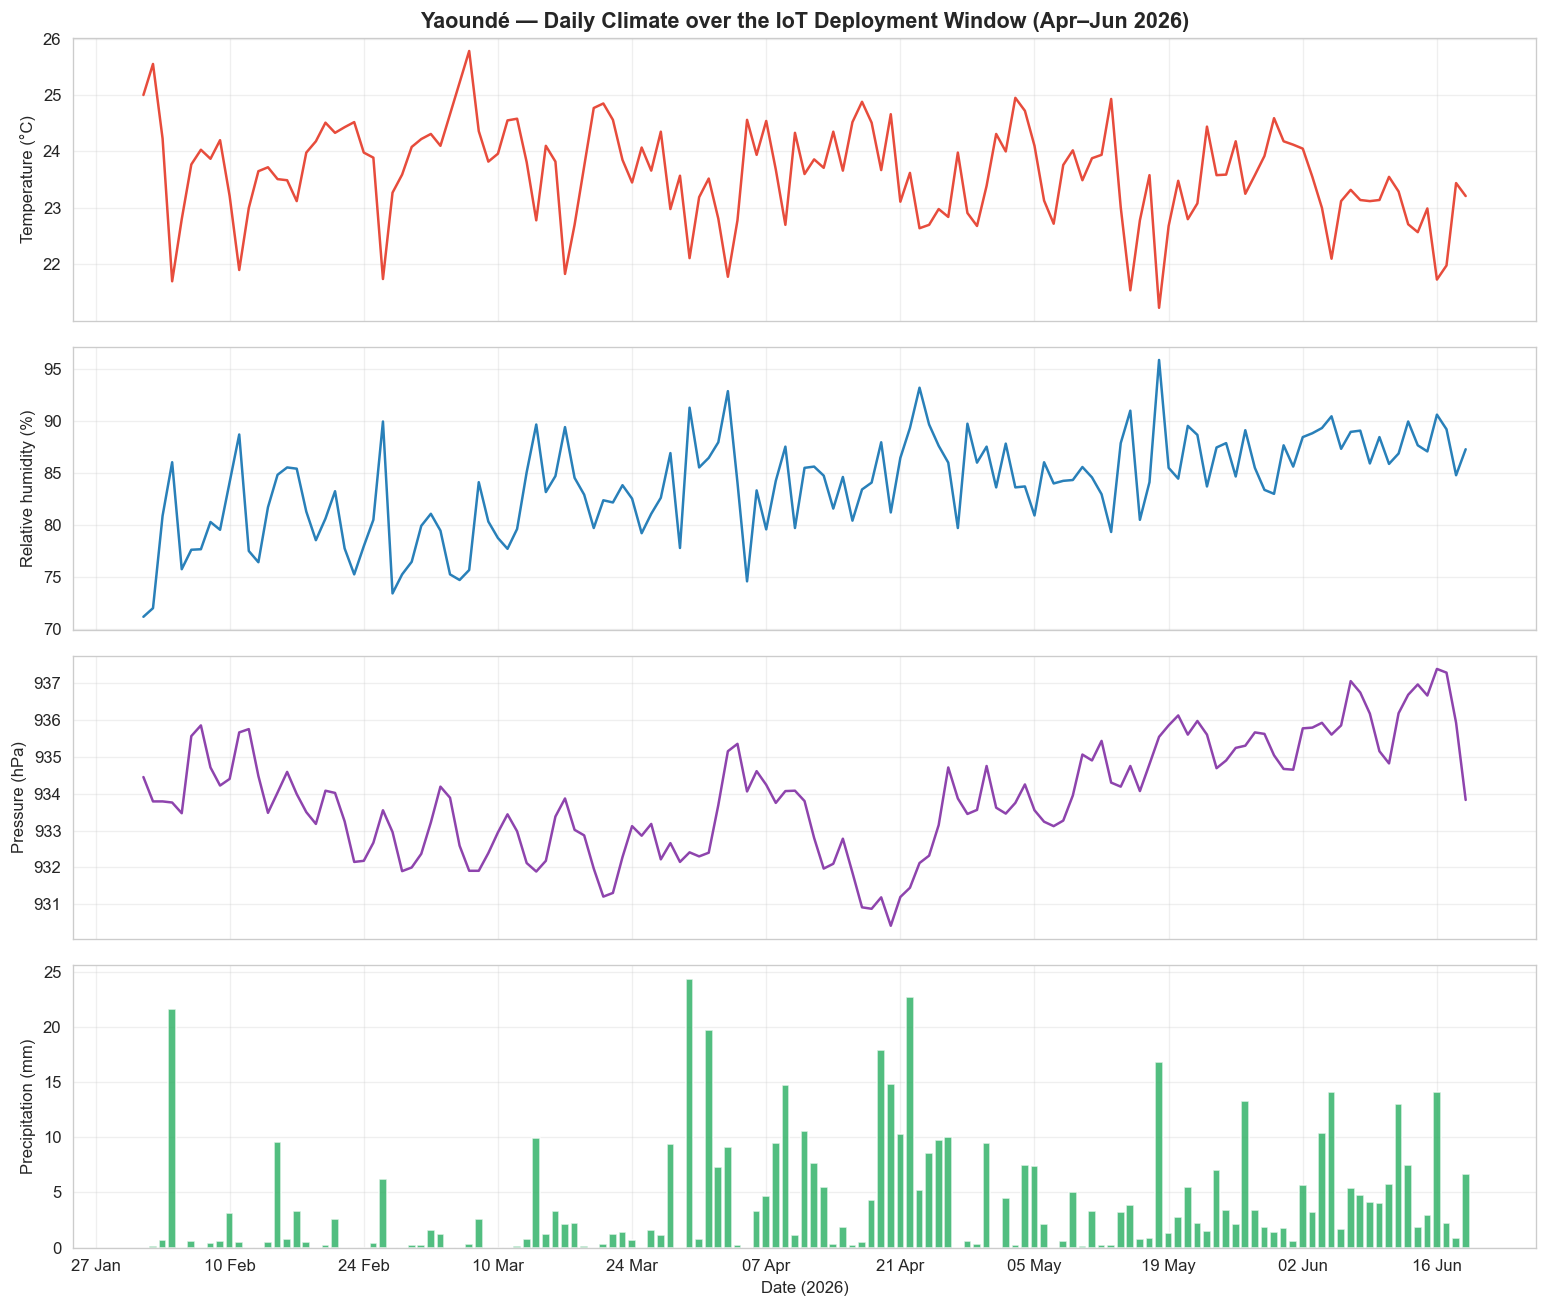

Saved yde_climate_2026.png


In [6]:
fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
for ax, v in zip(axes, vars_order):
    if v == 'Precipitation_mm':
        ax.bar(dep['Date'], dep[v], width=0.8, color=VARC[v], alpha=0.8)
    else:
        ax.plot(dep['Date'], dep[v], '-', color=VARC[v], lw=1.5)
    ax.set_ylabel(VARLAB[v]); ax.grid(True, alpha=0.3)
axes[0].set_title('Yaoundé — Daily Climate over the IoT Deployment Window (Apr–Jun 2026)',
                  fontsize=13, fontweight='bold')
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[-1].set_xlabel('Date (2026)')
plt.tight_layout()
plt.savefig('yde_climate_2026.png', bbox_inches='tight'); plt.show()
print('Saved yde_climate_2026.png')


## 6 · Figure — Deployment window in seasonal context

Overlays the Apr–Jun 2026 daily observations on the 2019–2022 monthly band for the
same months, situating the deployment period within the historical climate envelope.


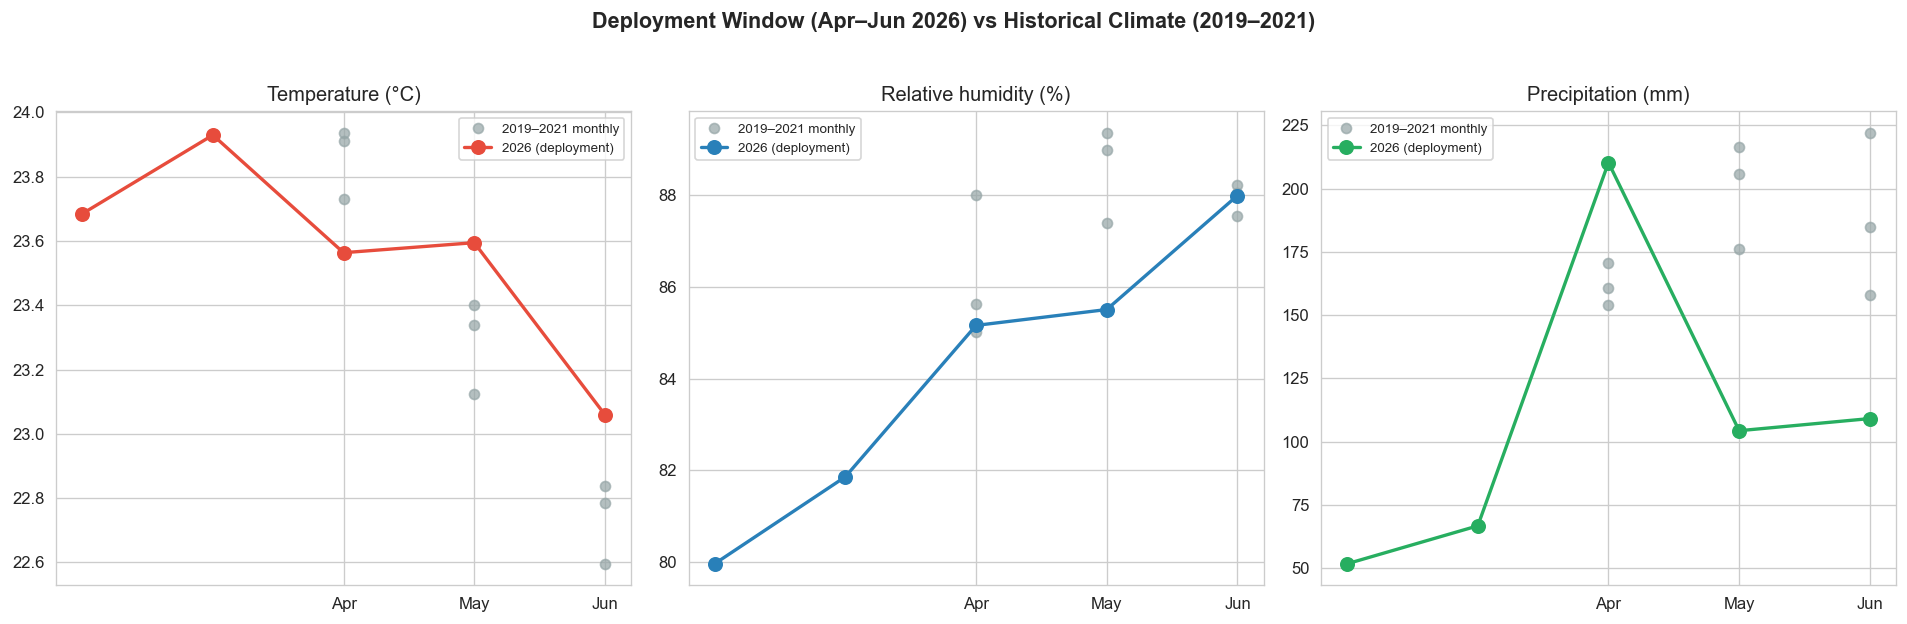

Saved yde_2026_vs_hist.png


In [9]:
# historical envelope for Apr-Jun across 2019-2021 (monthly)
hist_amj = monthly[monthly['Date'].dt.month.isin([4,5,6])]
dep_m = dep.copy(); dep_m['month'] = dep_m['Date'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, v in zip(axes, ['Temperature_C','Humidity','Precipitation_mm']):
    # historical monthly points (one per Apr/May/Jun per year)
    for m in [4,5,6]:
        hv = hist_amj[hist_amj['Date'].dt.month==m][v]
        ax.plot([m]*len(hv), hv,
        marker='o',
        linestyle='None',
        color='#95a5a6',
        alpha=0.7,
        ms=6,
        label='2019–2021 monthly' if m==4 else '')
    # 2026 daily aggregated to monthly for comparison
    if v=='Precipitation_mm':
        dep_month = dep_m.groupby('month')[v].sum()
    else:
        dep_month = dep_m.groupby('month')[v].mean()
    ax.plot(dep_month.index, dep_month.values, '-o', color=VARC[v], lw=2, ms=8,
            label='2026 (deployment)')
    ax.set_xticks([4,5,6]); ax.set_xticklabels(['Apr','May','Jun'])
    ax.set_title(VARLAB[v]); ax.legend(fontsize=8)
plt.suptitle('Deployment Window (Apr–Jun 2026) vs Historical Climate (2019–2021)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('yde_2026_vs_hist.png', bbox_inches='tight'); plt.show()
print('Saved yde_2026_vs_hist.png')


## 7 · Summary

The figures produced:

| File | Content |
|---|---|
| `yde_climate_2019_2022.png` | Monthly evolution of 4 variables, training period |
| `yde_climatology.png` | Mean seasonal cycle (bimodal rainfall) |
| `yde_climate_2026.png` | Daily evolution, deployment window |
| `yde_2026_vs_hist.png` | Deployment period vs historical envelope |

These characterise Yaoundé's equatorial climate: a stable temperature near
23–24 °C year-round, consistently high humidity, and the bimodal rainfall regime
with wet seasons around March–June and September–November. The deployment window
(April–June 2026) falls within the first wet season, which the comparison figure
situates against the 2019–2021 baseline.
